# Exploratory Data Analysis (EDA) — MASSIVE multilingual corpus

**Data:** the [MASSIVE](https://huggingface.co/datasets/mteb/amazon_massive_scenario) *scenario* dataset (Amazon), loaded natively in **English, Swedish and Finnish**. MASSIVE is *parallel* — the same utterances exist in every language — so all three languages share one identical **18-class** label space (`alarm`, `calendar`, `weather`, …) with **no translation step**.

The OOP data layer (`MassiveScenarioFetcher` → `MultilingualCorpusFetcher`) returns the standardized schema **`text | label | label_text | language`**, persisted to `data/processed_data/multilingual_corpus.csv` by [utils/build_multilingual_dataset.py](utils/build_multilingual_dataset.py).

In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from loguru import logger

# Make the repo root importable so the custom utils package resolves.
sys.path.append('..')
# OOP data-fetching layer: returns the standardized schema
# (text | label | label_text | language) for any MASSIVE language.
from utils.data_fetcher import MassiveScenarioFetcher

### EDA Class Definition
**Purpose:** Defines the `TextExploratoryAnalyzer` class, which encapsulates every data-quality and distribution check (strict OOP — one class, single-purpose methods, full error handling).

**Why "missing values" is different in NLP:** a text row is rarely a clean `NaN`. The damaging cases are *silent*:
- **NaN / Null** — the only case a `df.isnull()` check catches.
- **Empty / Whitespace ("ghost") docs** — strings that look present but become `""` after `.strip()` (only spaces/tabs/newlines).
- **Micro-docs (< 3 words)** — too short to give a self-attention model any context; effectively noise.

The analyzer reports all three as *mutually-exclusive* buckets (with a bar chart), then checks **duplicates**, the **document-length distribution + IQR outliers**, the **category distribution** (which labels dominate + imbalance ratio), and the **language breakdown**.

In [2]:
class TextExploratoryAnalyzer:
    """
    Encapsulates exploratory data analysis for a multi-language text corpus.

    Responsibilities:
        * NLP-aware data-quality checks (missing values beyond NaN, duplicates).
        * Document-length distribution and IQR-based outlier detection.
        * Category (label) and language distribution visualizations.
    """

    def __init__(self, dataframe: pd.DataFrame) -> None:
        """
        Args:
            dataframe (pd.DataFrame): The corpus to analyze.
        """
        try:
            self.dataframe = dataframe.copy()
            logger.info(
                f"Initialized TextExploratoryAnalyzer on {len(self.dataframe)} documents."
            )
        except Exception as e:
            logger.error(f"Failed to initialize TextExploratoryAnalyzer: {e}")
            raise

    # ------------------------------------------------------------------ #
    # 1. NLP MISSING VALUES  (NaN is only ONE of several "empty" states)
    # ------------------------------------------------------------------ #
    def analyze_missing_values(self, text_col: str, min_words: int = 3) -> pd.DataFrame:
        """
        Classifies every document into mutually-exclusive quality buckets, prints
        the counts/percentages, and plots them. In NLP a row is "missing" not only
        when it is NaN, but also when it is whitespace-only or too short to carry
        context for a self-attention model.

        Buckets:
            * NaN / Null              -> truly missing cells
            * Empty / Whitespace      -> "ghost" docs (only spaces, tabs, newlines)
            * Micro (< ``min_words``) -> too few tokens for meaningful context
            * Valid                   -> usable documents

        Args:
            text_col (str): Column holding the document text.
            min_words (int): Threshold under which a document is a "micro" doc.

        Returns:
            pd.DataFrame: Summary table with counts and percentages.
        """
        try:
            series = self.dataframe[text_col]
            total = len(series)

            is_nan = series.isnull()
            stripped = series.fillna("").astype(str).str.strip()
            word_counts = stripped.str.split().map(len)

            is_empty = (~is_nan) & (stripped == "")
            is_micro = (~is_nan) & (stripped != "") & (word_counts < min_words)
            is_valid = (~is_nan) & (word_counts >= min_words)

            summary = pd.DataFrame(
                {
                    "category": [
                        "NaN / Null",
                        "Empty / Whitespace",
                        f"Micro (<{min_words} words)",
                        "Valid",
                    ],
                    "count": [
                        int(is_nan.sum()),
                        int(is_empty.sum()),
                        int(is_micro.sum()),
                        int(is_valid.sum()),
                    ],
                }
            )
            summary["percent"] = (summary["count"] / total * 100).round(2)

            logger.info("NLP missing-value analysis completed.")
            print("\n=== NLP Data Quality: Missing Values (not just NaN) ===")
            print(summary.to_string(index=False))
            print(f"Total documents: {total}\n")

            # Visualization: bar chart of the four mutually-exclusive buckets.
            plt.figure(figsize=(9, 5))
            colors = ["#d9534f", "#f0ad4e", "#f7e463", "#5cb85c"]
            bars = plt.bar(summary["category"], summary["count"], color=colors)
            for bar, pct in zip(bars, summary["percent"]):
                plt.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height(),
                    f"{int(bar.get_height())}\n({pct}%)",
                    ha="center",
                    va="bottom",
                    fontsize=9,
                )
            plt.title("NLP Missing-Value Taxonomy")
            plt.ylabel("Number of Documents")
            plt.xticks(rotation=15)
            plt.tight_layout()
            plt.show()

            return summary
        except KeyError as ke:
            logger.error(f"Text column '{text_col}' not found: {ke}")
            raise
        except Exception as e:
            logger.error(f"Error during missing-value analysis: {e}")
            raise

    # ------------------------------------------------------------------ #
    # 2. DUPLICATES  (leak across train/test splits and inflate metrics)
    # ------------------------------------------------------------------ #
    def analyze_duplicates(self, text_col: str) -> pd.DataFrame:
        """
        Detects exact duplicate documents, a common corpus contaminant.

        Args:
            text_col (str): Column holding the document text.

        Returns:
            pd.DataFrame: Counts of unique vs duplicate documents.
        """
        try:
            series = self.dataframe[text_col].fillna("").astype(str).str.strip()
            total = len(series)
            n_dup = int(series.duplicated(keep="first").sum())
            n_unique = int(series.nunique())

            logger.info(f"Duplicate analysis: {n_dup} duplicates, {n_unique} unique texts.")
            print("\n=== Duplicate Documents ===")
            print(f"Total documents:      {total}")
            print(f"Unique documents:     {n_unique}")
            print(f"Duplicate documents:  {n_dup} ({round(n_dup / total * 100, 2)}%)\n")

            summary = pd.DataFrame(
                {"category": ["Unique", "Duplicate"], "count": [total - n_dup, n_dup]}
            )

            plt.figure(figsize=(5, 5))
            plt.pie(
                summary["count"],
                labels=summary["category"],
                autopct="%1.1f%%",
                colors=["#5cb85c", "#d9534f"],
                startangle=90,
            )
            plt.title("Unique vs Duplicate Documents")
            plt.tight_layout()
            plt.show()

            return summary
        except KeyError as ke:
            logger.error(f"Text column '{text_col}' not found: {ke}")
            raise
        except Exception as e:
            logger.error(f"Error during duplicate analysis: {e}")
            raise

    # ------------------------------------------------------------------ #
    # 3. DOCUMENT LENGTH DISTRIBUTION + OUTLIERS
    # ------------------------------------------------------------------ #
    def analyze_document_length_distribution(
        self, text_col: str, min_words: int = 3
    ) -> pd.DataFrame:
        """
        Computes the document-length distribution (in words) and flags outliers
        with the IQR rule. Renders a histogram (distribution shape) and a boxplot
        (outliers). Empty/micro documents are excluded from the length statistics.

        Args:
            text_col (str): Column holding the document text.
            min_words (int): Minimum words for a document to enter the statistics.

        Returns:
            pd.DataFrame: ``describe()`` summary of the word-length distribution.
        """
        try:
            lengths = self.dataframe[text_col].fillna("").astype(str).str.split().map(len)
            lengths = lengths[lengths >= min_words]
            if lengths.empty:
                raise ValueError("No documents long enough to compute length statistics.")

            desc = lengths.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

            q1, q3 = lengths.quantile(0.25), lengths.quantile(0.75)
            iqr = q3 - q1
            lower_bound = max(0, q1 - 1.5 * iqr)
            upper_bound = q3 + 1.5 * iqr
            n_outliers = int(((lengths < lower_bound) | (lengths > upper_bound)).sum())

            logger.info(
                f"Document length -> median {lengths.median():.0f} words, "
                f"{n_outliers} IQR outliers (upper bound {upper_bound:.0f})."
            )
            print("\n=== Document Length Distribution (words) ===")
            print(desc.round(1).to_string())
            print(f"\nIQR outlier bounds: [{lower_bound:.0f}, {upper_bound:.0f}] words")
            print(
                f"Outlier documents:  {n_outliers} "
                f"({round(n_outliers / len(lengths) * 100, 2)}%)\n"
            )

            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            sns.histplot(lengths, bins=60, kde=True, color="teal", ax=axes[0])
            axes[0].axvline(
                lengths.median(), color="red", linestyle="--",
                label=f"median = {lengths.median():.0f}",
            )
            axes[0].axvline(
                upper_bound, color="orange", linestyle="--",
                label=f"upper IQR = {upper_bound:.0f}",
            )
            # Clip the x-axis to the 99th percentile so the bulk is readable
            # despite extreme long-tail outliers (the boxplot still shows them).
            axes[0].set_xlim(0, max(1, lengths.quantile(0.99)))
            axes[0].set_title("Document Length Distribution")
            axes[0].set_xlabel("Words per Document")
            axes[0].legend()

            sns.boxplot(x=lengths, color="skyblue", ax=axes[1])
            axes[1].set_title("Document Length Outliers (IQR)")
            axes[1].set_xlabel("Words per Document")
            plt.tight_layout()
            plt.show()

            return desc.to_frame(name="words")
        except KeyError as ke:
            logger.error(f"Text column '{text_col}' not found: {ke}")
            raise
        except Exception as e:
            logger.error(f"Error during length distribution analysis: {e}")
            raise

    # ------------------------------------------------------------------ #
    # 4. CATEGORY (LABEL) DISTRIBUTION
    # ------------------------------------------------------------------ #
    def plot_class_distribution(self, target_col: str) -> pd.DataFrame:
        """
        Visualizes category frequencies (sorted), reports the most/least common
        labels, and computes the class-imbalance ratio.

        Args:
            target_col (str): Column holding the category labels.

        Returns:
            pd.DataFrame: Per-category document counts (sorted descending).
        """
        try:
            counts = self.dataframe[target_col].value_counts()
            imbalance_ratio = (
                counts.max() / counts.min() if counts.min() > 0 else float("inf")
            )

            logger.info(
                f"Most common category: '{counts.idxmax()}' ({counts.max()} docs). "
                f"Imbalance ratio: {imbalance_ratio:.2f}."
            )
            print("\n=== Category (Label) Distribution ===")
            print(counts.to_string())
            print(f"\nMost common:  {counts.idxmax()} ({counts.max()} docs)")
            print(f"Least common: {counts.idxmin()} ({counts.min()} docs)")
            print(f"Imbalance ratio (max / min): {imbalance_ratio:.2f}\n")

            plt.figure(figsize=(12, 7))
            sns.barplot(
                x=counts.values,
                y=counts.index,
                hue=counts.index,
                palette="viridis",
                legend=False,
                orient="h",
            )
            plt.title("Document Category Distribution (sorted by frequency)")
            plt.xlabel("Number of Documents")
            plt.ylabel("Category")
            plt.tight_layout()
            plt.show()

            return counts.to_frame(name="count")
        except KeyError as ke:
            logger.error(f"Target column '{target_col}' not found: {ke}")
            raise
        except Exception as e:
            logger.error(f"Error plotting class distribution: {e}")
            raise

    # ------------------------------------------------------------------ #
    # 5. LANGUAGE DISTRIBUTION  (multi-language readiness)
    # ------------------------------------------------------------------ #
    def plot_language_distribution(self, lang_col: str = "language") -> pd.DataFrame:
        """
        Visualizes how documents are split across languages. Skips gracefully if
        the corpus has no language column yet.

        Args:
            lang_col (str): Column holding the ISO 639-1 language code.

        Returns:
            pd.DataFrame: Per-language document counts (empty if no language column).
        """
        try:
            if lang_col not in self.dataframe.columns:
                logger.warning(f"No '{lang_col}' column present; skipping language distribution.")
                print(
                    f"(No '{lang_col}' column found - the language breakdown will "
                    "populate once the Swedish/Finnish translations are added.)"
                )
                return pd.DataFrame()

            counts = self.dataframe[lang_col].value_counts()
            logger.info(f"Language distribution: {counts.to_dict()}")
            print("\n=== Language Distribution ===")
            print(counts.to_string())
            print()

            plt.figure(figsize=(7, 5))
            bars = plt.bar(counts.index.astype(str), counts.values, color="#4c72b0")
            for bar in bars:
                plt.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height(),
                    int(bar.get_height()),
                    ha="center",
                    va="bottom",
                )
            plt.title("Document Count per Language")
            plt.xlabel("Language")
            plt.ylabel("Number of Documents")
            plt.tight_layout()
            plt.show()

            return counts.to_frame(name="count")
        except Exception as e:
            logger.error(f"Error plotting language distribution: {e}")
            raise


### Execution Pipeline
**Purpose:** Fetch one language (English) of MASSIVE via `MassiveScenarioFetcher`, pass it into `TextExploratoryAnalyzer`, and run the full data-quality + distribution report: NLP missing values → duplicates → length distribution & outliers → category balance → language breakdown. Each method returns its summary table so the numbers can be reused later (e.g. in the dashboard).

*Note:* MASSIVE utterances are short voice-assistant commands (often 1–4 words), so the "micro document" threshold is set to `min_words=1` — only truly empty rows count as missing.


=== NLP Data Quality: Missing Values (not just NaN) ===
          category  count  percent
        NaN / Null      0      0.0
Empty / Whitespace      0      0.0
  Micro (<1 words)      0      0.0
             Valid  11514    100.0
Total documents: 11514


=== Duplicate Documents ===
Total documents:      11514
Unique documents:     11468
Duplicate documents:  46 (0.4%)


=== Document Length Distribution (words) ===
count    11514.0
mean         6.9
std          3.3
min          1.0
25%          5.0
50%          6.0
75%          9.0
90%         11.0
95%         13.0
99%         17.0
max         35.0

IQR outlier bounds: [0, 15] words
Outlier documents:  217 (1.88%)


=== Category (Label) Distribution ===
label_text
calendar          1688
play              1377
qa                1183
email              953
iot                769
general            652
weather            573
transport          571
lists              539
news               503
recommendation     433
datetime           402

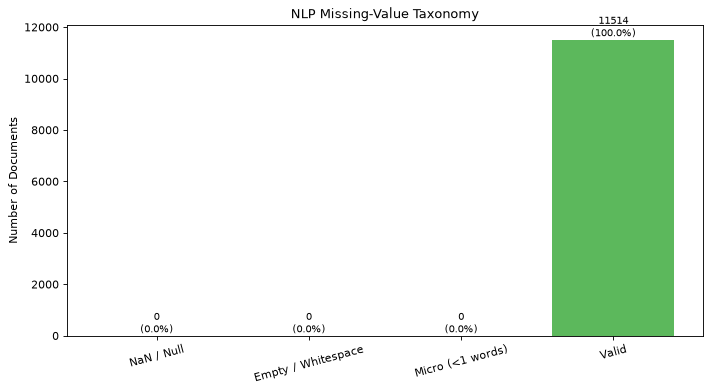

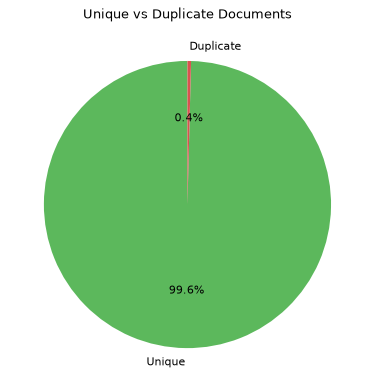

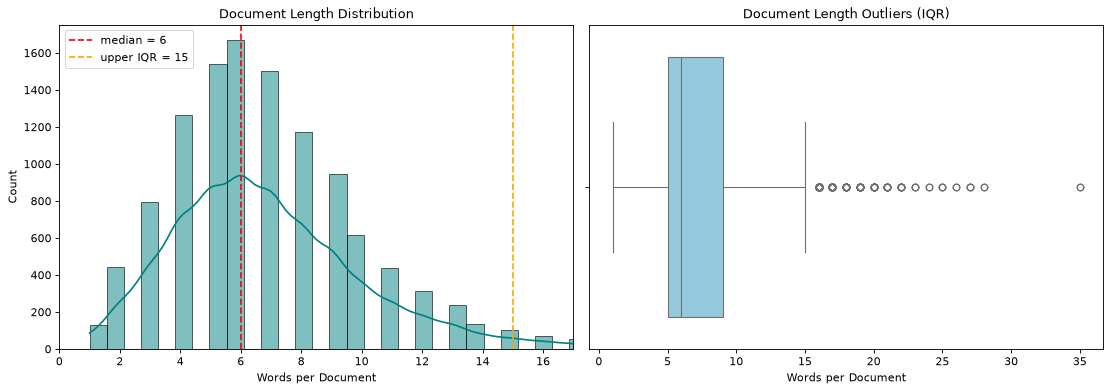

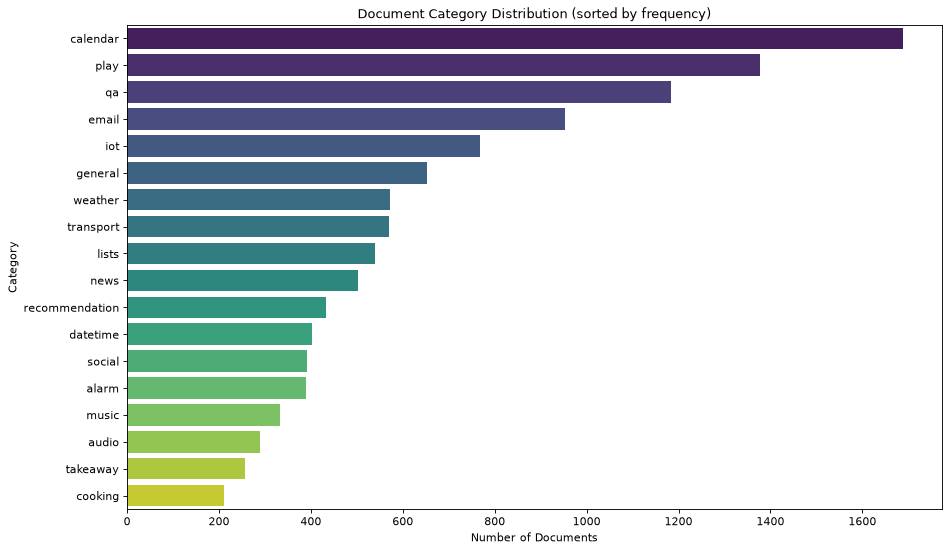

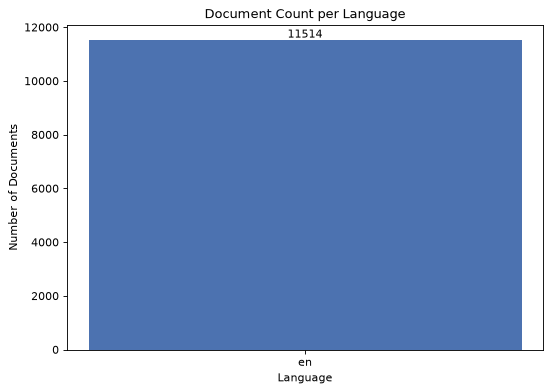

In [3]:
# Single-language EDA (English) through the OOP fetching layer.
try:
    logger.info("Fetching English MASSIVE via MassiveScenarioFetcher...")
    raw_df = MassiveScenarioFetcher("en").fetch()
    logger.info(f"Loaded corpus shape {raw_df.shape} with columns {list(raw_df.columns)}.")

    analyzer = TextExploratoryAnalyzer(raw_df)
    analyzer.analyze_missing_values(text_col="text", min_words=1)
    analyzer.analyze_duplicates(text_col="text")
    analyzer.analyze_document_length_distribution(text_col="text", min_words=1)
    analyzer.plot_class_distribution(target_col="label_text")
    analyzer.plot_language_distribution(lang_col="language")
except Exception as main_err:
    logger.error(f"EDA Pipeline execution failed: {main_err}")

## Build / load the multi-language corpus

The full English + Swedish + Finnish corpus is assembled by
[utils/build_multilingual_dataset.py](utils/build_multilingual_dataset.py): it loads each MASSIVE
language, applies the language-specific cleaning pipeline, and saves
`data/processed_data/multilingual_corpus.csv`. From the repo root:

```bash
python -m utils.build_multilingual_dataset                    # full corpus (~34.5k docs)
python -m utils.build_multilingual_dataset --sample-size 1200 # quick, stratified build
```

The cell below builds it only if the CSV is missing, then we run the multilingual EDA.

In [4]:
import os
from utils import config

try:
    if not os.path.exists(config.CORPUS_PATH):
        logger.info("Corpus not found — building the MASSIVE corpus (en/sv/fi)...")
        from utils.build_multilingual_dataset import build
        build()
    else:
        logger.info(f"Corpus already present at {config.CORPUS_PATH}.")
except Exception as e:
    logger.error(f"Corpus build/load failed: {e}")

### Multi-Language EDA: native Swedish & Finnish

Swedish and Finnish in MASSIVE are **native text**, not translations. We load the saved corpus and run the **same** EDA per language, then compare them — confirming the shared 18-class label space and the near-identical length profiles across the three parallel languages.


========================= English =========================

=== NLP Data Quality: Missing Values (not just NaN) ===
          category  count  percent
        NaN / Null      0      0.0
Empty / Whitespace      0      0.0
  Micro (<1 words)      0      0.0
             Valid  11514    100.0
Total documents: 11514


=== Category (Label) Distribution ===
label_text
calendar          1688
play              1377
qa                1183
email              953
iot                769
general            652
weather            573
transport          571
lists              539
news               503
recommendation     433
datetime           402
social             391
alarm              390
music              332
audio              290
takeaway           257
cooking            211

Most common:  calendar (1688 docs)
Least common: cooking (211 docs)
Imbalance ratio (max / min): 8.00


========================= Swedish =========================

=== NLP Data Quality: Missing Values (not just NaN) =

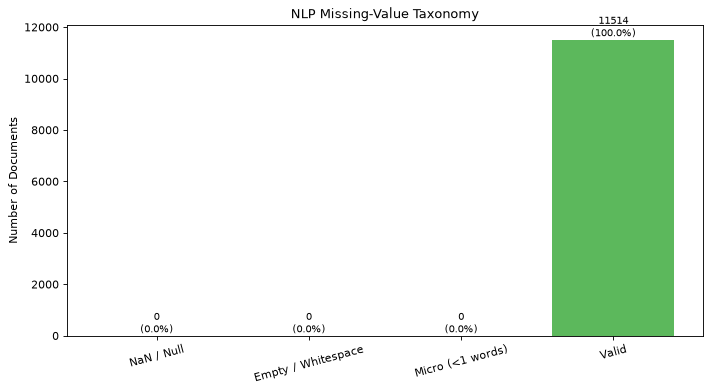

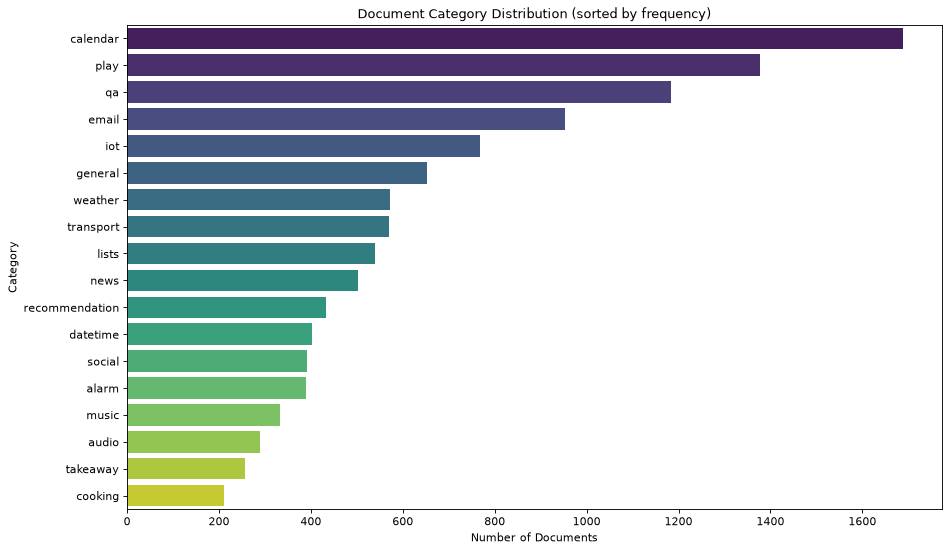

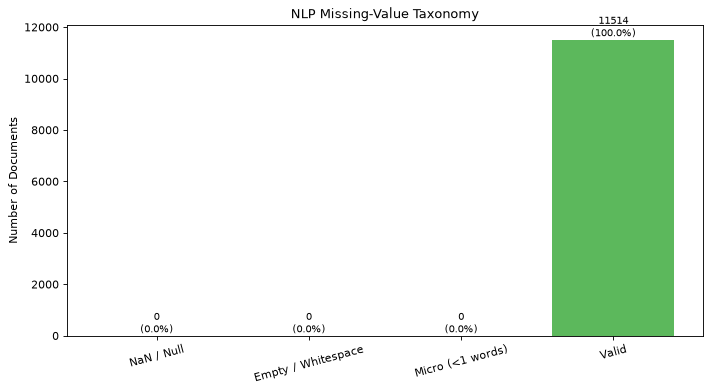

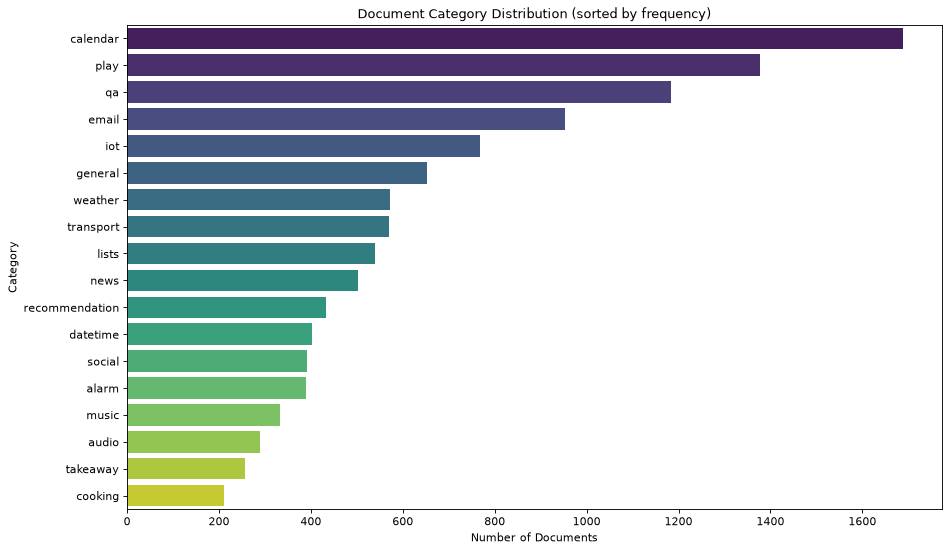

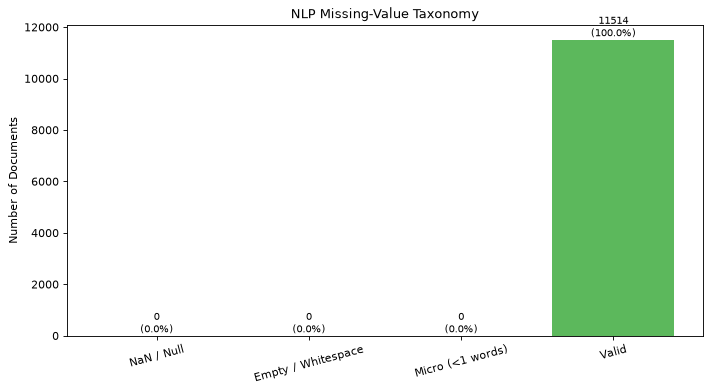

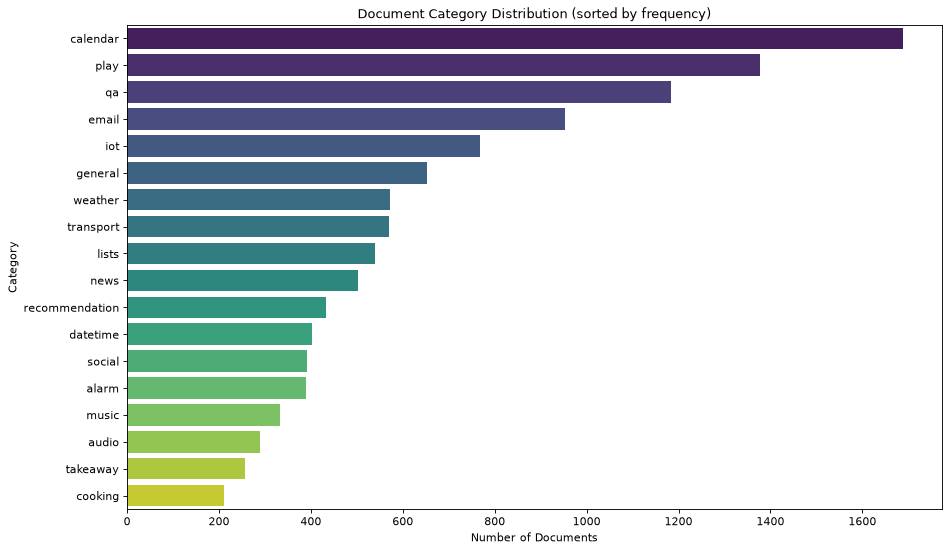

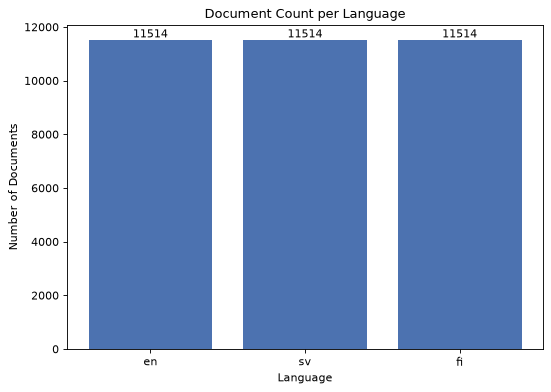

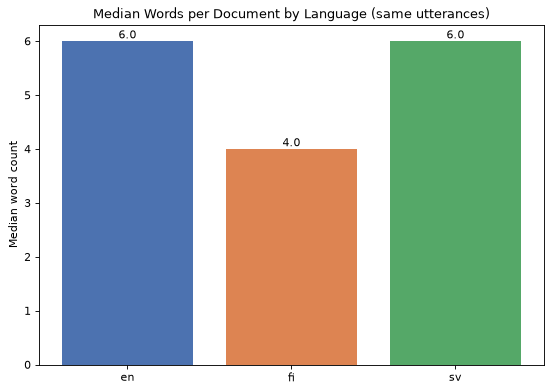

In [5]:
# Multi-language EDA: load the saved corpus and run the SAME EDA per language.
import os
from utils import config

try:
    if not os.path.exists(config.CORPUS_PATH):
        logger.warning(f"{config.CORPUS_PATH} not found.")
        print("Corpus not found. Build it first: python -m utils.build_multilingual_dataset")
    else:
        multilingual_df = pd.read_csv(config.CORPUS_PATH)
        logger.info(
            f"Loaded {len(multilingual_df)} docs: "
            f"{multilingual_df['language'].value_counts().to_dict()}"
        )

        # The SAME EDA, per language (native EN / SV / FI).
        for _code, _name in [("en", "English"), ("sv", "Swedish"), ("fi", "Finnish")]:
            _frame = multilingual_df[multilingual_df["language"] == _code]
            if _frame.empty:
                continue
            print(f"\n{'=' * 25} {_name} {'=' * 25}")
            _a = TextExploratoryAnalyzer(_frame)
            _a.analyze_missing_values(text_col="text", min_words=1)
            _a.plot_class_distribution(target_col="label_text")

        # Whole-corpus language breakdown.
        TextExploratoryAnalyzer(multilingual_df).plot_language_distribution(lang_col="language")

        # Cross-language comparison: median words per document (same utterances).
        _medians = {
            lang: g["text"].astype(str).str.split().map(len).median()
            for lang, g in multilingual_df.groupby("language")
        }
        plt.figure(figsize=(7, 5))
        plt.bar(_medians.keys(), _medians.values(), color=["#4c72b0", "#dd8452", "#55a868"])
        for _i, (_lang, _val) in enumerate(_medians.items()):
            plt.text(_i, _val, f"{_val:.1f}", ha="center", va="bottom")
        plt.title("Median Words per Document by Language (same utterances)")
        plt.ylabel("Median word count")
        plt.tight_layout()
        plt.show()
except Exception as e:
    logger.error(f"Multi-language EDA failed: {e}")

## Phase 2: Classification Engine Training
**Purpose:** This phase establishes a traditional machine learning baseline (TF-IDF + Logistic Regression) and then fine-tunes a deep learning architecture (DistilBERT) to compare their F1-Macro, AUC, and Accuracy metrics.

**Important Note:** We must set the environment variable to force legacy Keras compatibility before importing our models.

In [ ]:
# CRITICAL: configure the HF backend BEFORE importing the classification models.
# Legacy Keras for the TF training APIs, and torch OFF so transformers stays
# TensorFlow-only (avoids the macOS TF+PyTorch OpenMP "mutex lock failed" abort).
%env TF_USE_LEGACY_KERAS=1
%env USE_TORCH=0

import sys
import pandas as pd
from sklearn.model_selection import train_test_split
from loguru import logger

sys.path.append('..')
from models.text_classifier import BaselineClassifier, DistilBertClassifier

### Data Preparation, Cleaning & Splitting
**Purpose:** Load the built **multi-language corpus** (English + Swedish + Finnish), clean each document with `LanguageSpecificSanitizer` — HTML/newsgroup-noise/URL/email removal, unicode normalization, whitespace collapse — **routing by the known `language` column** (no runtime detection). Documents that become empty or too short after cleaning are dropped, then we apply a stratified 80/20 split across all languages. The resulting `X_train/X_val` feed both the baseline and DistilBERT.

In [ ]:
import os
import pandas as pd
from tqdm.auto import tqdm
from utils.text_cleaning import LanguageSpecificSanitizer, CleaningObservabilityDecorator
from loguru import logger

# 1. PREVENT JUPYTER CRASH: Reconfigure Loguru
logger.remove()  # Remove the default noisy logger
logger.add(sys.stderr, level="INFO")  # Show INFO and above in the cell
logger.add("cleaning_observability.log", level="DEBUG")  # Heavy DEBUG logs go to file

tqdm.pandas()  # Enable progress bars for pandas

CORPUS_PATH = "../data/processed_data/multilingual_corpus.csv"

try:
    if not os.path.exists(CORPUS_PATH):
        raise FileNotFoundError(
            f"{CORPUS_PATH} not found - run the 'Build the Multi-Language Corpus' cell first."
        )

    logger.info("Loading the multi-language corpus for training...")
    train_corpus = pd.read_csv(CORPUS_PATH)
    logger.info(f"Corpus languages: {train_corpus['language'].value_counts().to_dict()}")

    # Route by the KNOWN language column (no detection needed). One sanitizer/lang.
    sanitizers = {
        lang: CleaningObservabilityDecorator(LanguageSpecificSanitizer(lang))
        for lang in ("en", "sv", "fi")
    }

    def preprocess_row(row) -> str:
        """Clean one document using its KNOWN language; drop empty/micro docs."""
        text = row["text"]
        if not text or not str(text).strip():
            return None
        try:
            sanitizer = sanitizers.get(row["language"], sanitizers["en"])
            cleaned = sanitizer.clean(str(text))
            # Drop docs that became empty/too short after cleaning (e.g. all-quotes).
            return cleaned if len(cleaned.split()) >= 1 else None
        except Exception:
            return None

    logger.info("Applying cleaning pipeline (routing by known language)...")
    train_corpus["clean_text"] = train_corpus.progress_apply(preprocess_row, axis=1)

    clean_df = train_corpus.dropna(subset=["clean_text"]).copy()
    logger.info(f"Dropped {len(train_corpus) - len(clean_df)} invalid/empty documents after cleaning.")

    X_clean = clean_df["clean_text"].tolist()
    y_clean = clean_df["label"].tolist()

    # Stratified Split: 80% Training, 20% Validation (across all languages)
    X_train, X_val, y_train, y_val = train_test_split(
        X_clean, y_clean,
        test_size=0.2,
        random_state=42,
        stratify=y_clean,
    )
    logger.info(f"Training samples: {len(X_train)} | Validation samples: {len(X_val)}")
except Exception as e:
    logger.error(f"Data preparation failed: {e}")

### Step 1: The Baseline Model
**Purpose:** Train a Bag-of-Words Logistic Regression model. This gives us our "floor" metrics that the Deep Learning model must outperform by at least 5%.

In [ ]:
try:
    logger.info("--- Starting Baseline Training ---")
    baseline = BaselineClassifier(max_features=10000)
    baseline.train(X_train, y_train, X_val, y_val)
    
    logger.info("Baseline Evaluation completed.")
except Exception as e:
    logger.error(f"Baseline execution failed: {e}")

### Step 2: Fine-Tuning DistilBERT
**Purpose:** Fine-tune the pre-trained DistilBERT transformer over 5 epochs. Callbacks will automatically save the `text_classifier_best.weights.h5`, `config.json`, and `training_history.csv` to the `models/checkpoints/` directory.

In [ ]:
try:
    logger.info("--- Starting DistilBERT Fine-Tuning ---")
    # Derive the number of classes from the data (robust to label-set changes).
    num_classes = len(set(y_train))
    dl_model = DistilBertClassifier(num_classes=num_classes)

    # Train for 5 epochs (as required by the issue specs).
    dl_model.train(X_train, y_train, X_val, y_val, epochs=5)

    logger.info("Evaluating DistilBERT on Validation Set:")
    dl_metrics = dl_model.evaluate(X_val, y_val)
except Exception as e:
    logger.error(f"DistilBERT execution failed: {e}")